In [25]:

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 
import gensim

print(gensim.__version__)

4.3.3


## Embeddings 
-  Embedding Layer : Neural network 
- **Word2Vec** 
=> Word2Vec is a statistical method for efficiently learning a standalone word embedding from a
text corpus. It was developed by Tomas Mikolov, et al. at Google in 2013 as a response to make
the neural-network-based training of the embedding more efficient and since then has become
the de facto standard for developing pre-trained word embedding.
Additionally, the work involved analysis of the learned vectors and the exploration of vector
math on the representations of words. For example, that subtracting the man-ness from King
and adding women-ness results in the word Queen, capturing the analogy king is to queen as
man is to woman.


- **CBOW and Skip Gram** 
=> The CBOW model learns the embedding by predicting the current word based on its context.
The continuous skip-gram model learns by predicting the surrounding words given a current
word.
-  Glove 


## TABLE OF CONTENTS 

- Word2Vec 
- Glove 
- Standford Glove Embeddings



In [2]:
sentences = [
['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
['this', 'is', 'the', 'second', 'sentence'],
['yet', 'another', 'sentence'],
['one', 'more', 'sentence'],
['and', 'the', 'final', 'sentence']
]



### 1) Word2Vec

In [3]:
model =  Word2Vec(sentences,min_count=1)
print(model)


words =  list(model.wv.key_to_index.keys())
vectors =  list(model.wv.vectors) ## all the embeddings 

print("Length of the words :",len(words))
print(words)
print("Length of the embedding matrix :",len(vectors))
print(vectors)

Word2Vec<vocab=14, vector_size=100, alpha=0.025>
Length of the words : 14
['sentence', 'the', 'is', 'this', 'final', 'and', 'more', 'one', 'another', 'yet', 'second', 'word2vec', 'for', 'first']
Length of the embedding matrix : 14
[array([-5.3622725e-04,  2.3643136e-04,  5.1033497e-03,  9.0092728e-03,
       -9.3029495e-03, -7.1168090e-03,  6.4588725e-03,  8.9729885e-03,
       -5.0154282e-03, -3.7633716e-03,  7.3805046e-03, -1.5334714e-03,
       -4.5366134e-03,  6.5540518e-03, -4.8601604e-03, -1.8160177e-03,
        2.8765798e-03,  9.9187379e-04, -8.2852151e-03, -9.4488179e-03,
        7.3117660e-03,  5.0702621e-03,  6.7576934e-03,  7.6286553e-04,
        6.3508903e-03, -3.4053659e-03, -9.4640139e-04,  5.7685734e-03,
       -7.5216377e-03, -3.9361035e-03, -7.5115822e-03, -9.3004224e-04,
        9.5381187e-03, -7.3191668e-03, -2.3337686e-03, -1.9377411e-03,
        8.0774371e-03, -5.9308959e-03,  4.5162440e-05, -4.7537340e-03,
       -9.6035507e-03,  5.0072931e-03, -8.7595852e-03, -4.

In [4]:
# acces from a single sentence
print(model.wv["sentence"])


[-5.3622725e-04  2.3643136e-04  5.1033497e-03  9.0092728e-03
 -9.3029495e-03 -7.1168090e-03  6.4588725e-03  8.9729885e-03
 -5.0154282e-03 -3.7633716e-03  7.3805046e-03 -1.5334714e-03
 -4.5366134e-03  6.5540518e-03 -4.8601604e-03 -1.8160177e-03
  2.8765798e-03  9.9187379e-04 -8.2852151e-03 -9.4488179e-03
  7.3117660e-03  5.0702621e-03  6.7576934e-03  7.6286553e-04
  6.3508903e-03 -3.4053659e-03 -9.4640139e-04  5.7685734e-03
 -7.5216377e-03 -3.9361035e-03 -7.5115822e-03 -9.3004224e-04
  9.5381187e-03 -7.3191668e-03 -2.3337686e-03 -1.9377411e-03
  8.0774371e-03 -5.9308959e-03  4.5162440e-05 -4.7537340e-03
 -9.6035507e-03  5.0072931e-03 -8.7595852e-03 -4.3918253e-03
 -3.5099984e-05 -2.9618145e-04 -7.6612402e-03  9.6147433e-03
  4.9820580e-03  9.2331432e-03 -8.1579173e-03  4.4957981e-03
 -4.1370760e-03  8.2453608e-04  8.4986202e-03 -4.4621765e-03
  4.5175003e-03 -6.7869602e-03 -3.5484887e-03  9.3985079e-03
 -1.5776526e-03  3.2137157e-04 -4.1406299e-03 -7.6826881e-03
 -1.5080082e-03  2.46979

### Visualizing words embeddings 

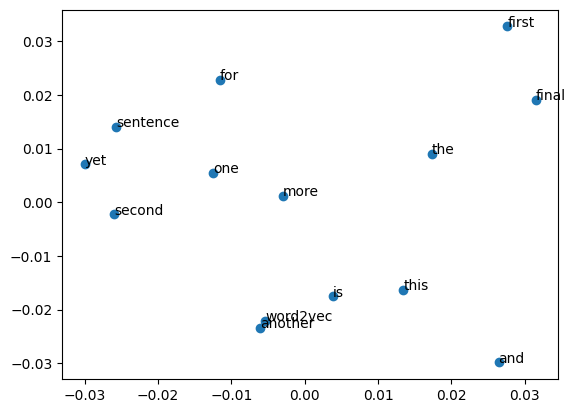

In [13]:
X = model.wv[model.wv.index_to_key]
pca=  PCA(n_components=2)
x_transformed =  pca.fit_transform(X)

plt.scatter(x_transformed[:,0],x_transformed[:,1])


for i , word in enumerate(words) :
    plt.annotate(word,xy=(x_transformed[i,0],x_transformed[i,1]))
    
plt.show()


### 2) Glove 

downloaded via : GoogleNews-vectors-negative300.bin.gz.
https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing

In [19]:
filename=  "GoogleNews-vectors-negative300.bin"
model = KeyedVectors.load_word2vec_format(filename, binary=True)

## ⌛⌛⌛⌛


In [24]:
result = model.most_similar(positive=['woman', 'handsome'], negative=['man'], topn=3)
result

[('shapely', 0.5564577579498291),
 ('comely', 0.5341092944145203),
 ('bosomy', 0.524068295955658)]

### 3) Standford Glove 
Downloaded via :  glove.6B.zip.
http://nlp.stanford.edu/data/glove.6B.zip

In [ ]:
## conversion of text file to word2vec file 
glove_input_file = 'glove.6B.100d.txt'
word2vec_output_file = 'glove.6B.100d.txt.word2vec'
glove2word2vec(glove_input_file, word2vec_output_file)


C:\Users\RISHABH\AppData\Local\Temp\ipykernel_21036\2032746246.py:3: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


(400000, 100)

In [27]:
## Now laod the model 

filename = 'glove.6B.100d.txt.word2vec'
model = KeyedVectors.load_word2vec_format(filename, binary=False)

In [28]:
result = model.most_similar(positive=['woman', 'handsome'], negative=['man'], topn=3)
print(result)


[('vivacious', 0.6452846527099609), ('voluptuous', 0.6431179642677307), ('charming', 0.6403611898422241)]
